### Set Up

In [1]:
# Base Modules
import pandas as pd
import numpy as np
import time
from datetime import datetime

# Plotting modules
import matplotlib.pyplot as plt

# Trading modules
import krakenex
from pykrakenapi import KrakenAPI
import requests

In [2]:
with open('KrakenPass.txt') as f:
    key = f.readline().strip()
    secret = f.readline().strip()

In [3]:
# Connect to api
api = krakenex.API(key=key, secret=secret)
k = KrakenAPI(api)

In [4]:
response = api.query_private('Balance')

if response['error']:
    print("Error:", response['error'])
else:
    print("API Key works! Here's your balance:")
    print(response['result'])

API Key works! Here's your balance:
{'ZUSD': '500.0000'}


## Get Time Series Data

In [95]:
# 1 (1 minute)
# 5 (5 minutes)
# 15 (15 minutes)
# 30 (30 minutes)
# 60 (1 hour)
# 240 (4 hours)
# 720 (12 hours)
# 1440 (1 day)
# 10080 (1 week)
# 21600 (15 days)​

In [96]:
valid_pairs = [
    # Core Majors
    ('XBTUSD', 'XXBTZUSD'),
    ('ETHUSD', 'XETHZUSD'),
    ('LINKUSD', 'LINKUSD'),
    ('DOTUSD', 'DOTUSD'),

    # High-Volatility, Lower-Correlation Altcoins
    ('MATICUSD', 'MATICUSD'),     # Ethereum L2 / scaling
    ('XMRUSD', 'XXMRZUSD'),       # Privacy, trades on separate narratives
    ('ATOMUSD', 'ATOMUSD'),       # Cosmos ecosystem
    ('ALGOUSD', 'ALGOUSD'),       # Layer 1, often depegged from majors
    ('KAVAUSD', 'KAVAUSD'),       # DeFi, very volatile
    ('GRTUSD', 'GRTUSD'),         # Web3 indexing
    ('CRVUSD', 'CRVUSD'),         # DeFi LP token
    ('1INCHUSD', '1INCHUSD'),     # DEX aggregator token
    ('MINAUSD', 'MINAUSD')        # ZK Layer 1, niche and volatile
]


In [97]:
def fetch_ohlc(pair_key, interval=1440):
    url = 'https://api.kraken.com/0/public/OHLC'
    params = {'pair': pair_key, 'interval': interval}
    resp = requests.get(url, params=params).json()

    if resp['error']:
        raise ValueError(f"Kraken error for pair {pair_key}: {resp['error']}")

    data = resp['result'][pair_key]
    df = pd.DataFrame(data, columns=[
        'time', 'open', 'high', 'low', 'close', 'vwap', 'volume', 'count'
    ])
    df['time'] = pd.to_datetime(df['time'], unit='s')
    df['close'] = df['close'].astype(float)
    return df

In [98]:
all_dfs = []
interval = 240  

In [99]:
for altname, key in valid_pairs:
    try:
        df = fetch_ohlc(key, interval=interval)
        df['coin'] = altname
        all_dfs.append(df[['coin', 'time', 'close']])
    except Exception as e:
        print(f"Error fetching {altname}: {e}")


In [100]:
if all_dfs:
    df_all = pd.concat(all_dfs).sort_values(['coin', 'time']).reset_index(drop=True)
    df_all.rename(columns={'time': 'datetime', 'close': 'price'}, inplace=True)
    df_all.to_csv('kraken_ohlc_history.csv', index=False)

In [101]:
print(df_all['datetime'].min())
df_all.head(2)

2025-01-01 00:00:00


,coin,datetime,price
0,1INCHUSD,2025-01-01 00:00:00,0.383
1,1INCHUSD,2025-01-01 04:00:00,0.381


In [102]:
df_wide = df_all.pivot(index='datetime', columns='coin', values='price')
df_wide = df_wide.sort_index()
df_wide.head()

coin,1INCHUSD,ALGOUSD,ATOMUSD,CRVUSD,DOTUSD,ETHUSD,GRTUSD,KAVAUSD,LINKUSD,MATICUSD,MINAUSD,XBTUSD,XMRUSD
datetime,,,,,,,,,,,,,
2025-01-01 00:00:00,0.383,0.33538,6.1939,0.908,6.6542,3347.10,0.19988,0.4464,20.03606,0.4496,0.577,93625.1,194.46
2025-01-01 04:00:00,0.381,0.33423,6.1368,0.906,6.6357,3338.99,0.19918,0.4447,19.93910,0.4516,0.574,93518.7,195.31
2025-01-01 08:00:00,0.377,0.33600,6.1733,0.880,6.6080,3334.25,0.19880,0.4441,20.00969,0.4526,0.577,93278.1,193.00
2025-01-01 12:00:00,0.384,0.35420,6.3433,0.935,6.7878,3345.02,0.20283,0.4500,20.52679,0.4617,0.587,94189.8,195.16
2025-01-01 16:00:00,0.391,0.37576,6.5363,0.961,6.9818,3349.28,0.20830,0.4622,21.43238,0.4733,0.596,94440.1,196.18


### EDA

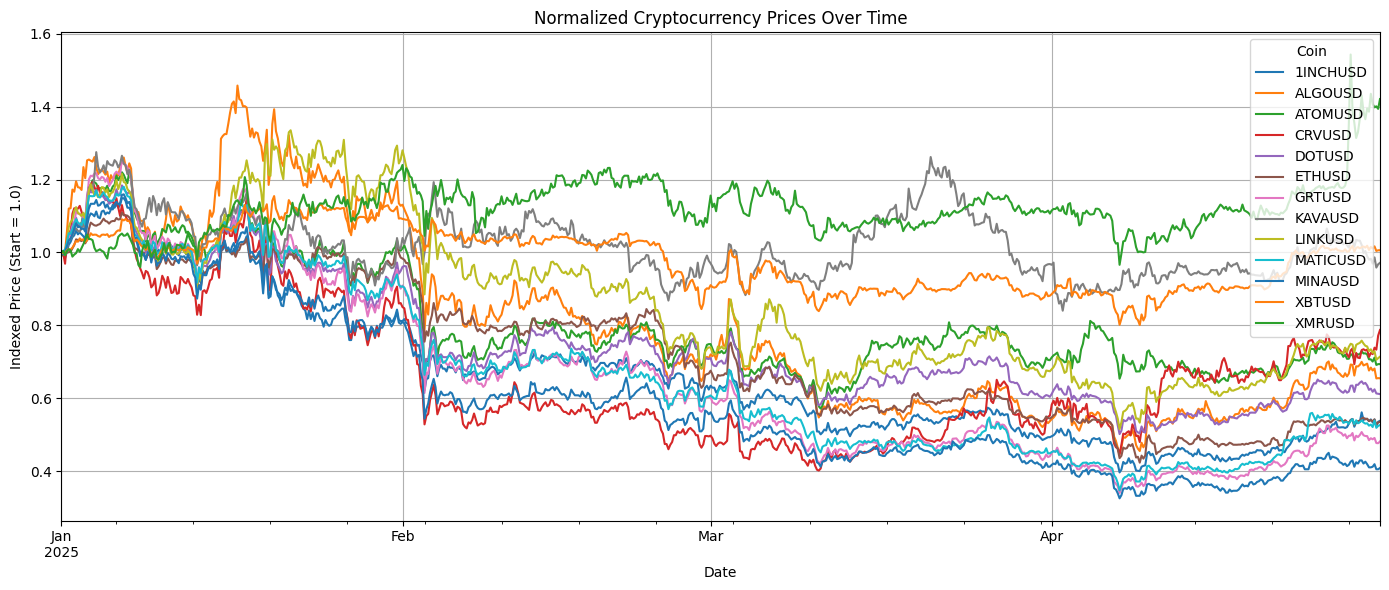

In [103]:
df_indexed = df_wide / df_wide.iloc[0]  # Divide each column by its first value
df_indexed.plot(figsize=(14, 6))

plt.title('Normalized Cryptocurrency Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Indexed Price (Start = 1.0)')
plt.legend(title='Coin')
plt.grid(True)
plt.tight_layout()
plt.show()

### Modeling

In [104]:
# Parameters
WINDOW = 180 # Number of days to calculate signal off of
PERIOD = 1 # Number of days of momentum

# Signals for buy or sell 
Z_SCORE_UB = 3 # Buy
Z_SCORE_LB = -1 # Sell

In [105]:
returns = df_wide.pct_change(PERIOD)

# Get rolling mean and SD
rolling_mean = returns.rolling(WINDOW).mean()
rolling_std = returns.rolling(WINDOW).std()

# Get Z-Score
z_score = (returns - rolling_mean) / rolling_std

In [106]:
# Buy/Sell signals
signals = pd.DataFrame(0, index=z_score.index, columns=z_score.columns)
signals[z_score > Z_SCORE_UB] = 1   # Buy signal
signals[z_score < Z_SCORE_LB] = -1 # Sell / short / avoid

<Axes: title={'center': 'Momentum Strategy Cumulative Return'}, xlabel='datetime'>

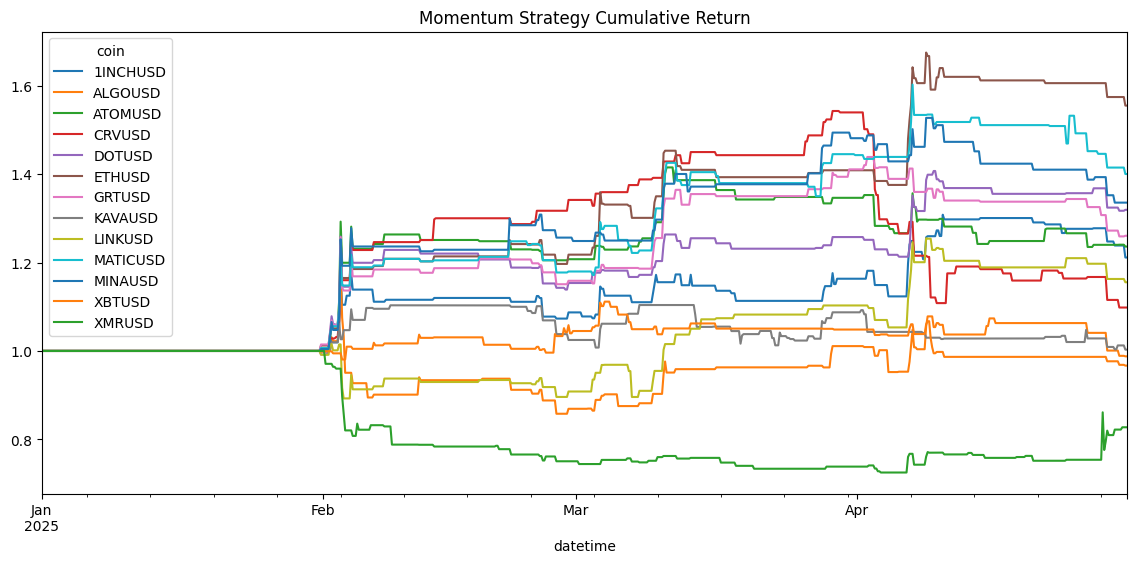

In [107]:
# Shift signal to avoid lookahead bias
positions = signals.shift(1)

# Daily returns
daily_returns = df_wide.pct_change()

# Strategy return: signal * return
strategy_returns = positions * daily_returns

# Cumulative return plot
(strategy_returns + 1).cumprod().plot(figsize=(14, 6), title="Momentum Strategy Cumulative Return")